In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt

DATA_DIR = '/content/drive/MyDrive/MIRAGE/data/raw/GSE98320'

clean_df = pd.read_csv(f'{DATA_DIR}/gse98320_master_pathology_labels.csv')
gene_expr_matrix = pd.read_parquet(f'{DATA_DIR}/gse98320_gene_expression.parquet')

with open(f'{DATA_DIR}/selected_genes_per_fold_k1000.json', 'r') as f:
    selected_genes_per_fold = json.load(f)

with open(f'{DATA_DIR}/classical_baseline_results.pkl', 'rb') as f:
    model_results = pickle.load(f)

print("Master table shape:", clean_df.shape)
print("Classical baselines loaded:", list(model_results.keys()))
for name, res in model_results.items():
    print(f"  {name}: mean macro-F1={res['mean_macro_f1']:.4f}")

Mounted at /content/drive
Master table shape: (1208, 20)
Classical baselines loaded: ['LASSO', 'Ridge', 'SVM', 'Random Forest', 'XGBoost']
  LASSO: mean macro-F1=0.7466
  Ridge: mean macro-F1=0.7392
  SVM: mean macro-F1=0.7540
  Random Forest: mean macro-F1=0.6770
  XGBoost: mean macro-F1=0.8035


In [2]:
banff_cols = ['g', 'cg', 'i', 'ci', 't', 'ct', 'v', 'cv', 'ah', 'ptc', 'c4d_ordinal']

def preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx):
    train_df = clean_df.loc[train_idx, banff_cols].copy()
    val_df = clean_df.loc[val_idx, banff_cols].copy()

    for col in banff_cols:
        train_df[f'{col}_was_missing'] = train_df[col].isna().astype(int)
        val_df[f'{col}_was_missing'] = val_df[col].isna().astype(int)

    medians = train_df[banff_cols].median()
    for col in banff_cols:
        train_df[col] = train_df[col].fillna(medians[col])
        val_df[col] = val_df[col].fillna(medians[col])

    return train_df, val_df, medians


fold_data = {}

for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index

    path_train, path_val, medians = preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx)

    train_gsms = clean_df.loc[train_idx, 'GSM'].values
    val_gsms = clean_df.loc[val_idx, 'GSM'].values

    gene_train_raw = gene_expr_matrix[train_gsms].T
    gene_val_raw = gene_expr_matrix[val_gsms].T

    gene_means = gene_train_raw.mean(axis=0)
    gene_stds = gene_train_raw.std(axis=0).replace(0, 1)

    gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
    gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

    fold_genes = selected_genes_per_fold[str(fold)]
    gene_train_selected = gene_train_scaled[fold_genes]
    gene_val_selected = gene_val_scaled[fold_genes]

    y_train = clean_df.loc[train_idx, 'mirage_label'].values
    y_val = clean_df.loc[val_idx, 'mirage_label'].values

    fold_data[fold] = {
        'path_train': path_train, 'path_val': path_val,
        'gene_train': gene_train_selected, 'gene_val': gene_val_selected,
        'y_train': y_train, 'y_val': y_val,
        'train_gsms': train_gsms, 'val_gsms': val_gsms,
    }

print("fold_data rebuilt.")
print({f: fold_data[f]['gene_train'].shape for f in range(5)})

fold_data rebuilt.
{0: (966, 1000), 1: (966, 1000), 2: (967, 1000), 3: (967, 1000), 4: (966, 1000)}


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

le = LabelEncoder()
le.fit(['NR', 'TCMR', 'ABMR', 'Mixed'])

class GeneMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout, num_classes=4):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp_one_fold(fold, hidden_dims, dropout, lr, weight_decay, epochs=100, patience=15):
    X_train = torch.tensor(fold_data[fold]['gene_train'].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold]['gene_val'].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
    y_val_t = torch.tensor(y_val_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    X_val_dev = X_val.to(device)
    y_val_dev = y_val_t.to(device)

    best_val_f1 = -1
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(X_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)

    return best_val_f1, final_preds, fold_data[fold]['y_val']


print("MLP class and training function defined.")

Using device: cuda
MLP class and training function defined.


small [64]: mean macro-F1=0.8005 (+/- 0.0169)
medium [128,64]: mean macro-F1=0.7926 (+/- 0.0255)
large [256,128,64]: mean macro-F1=0.8054 (+/- 0.0270)


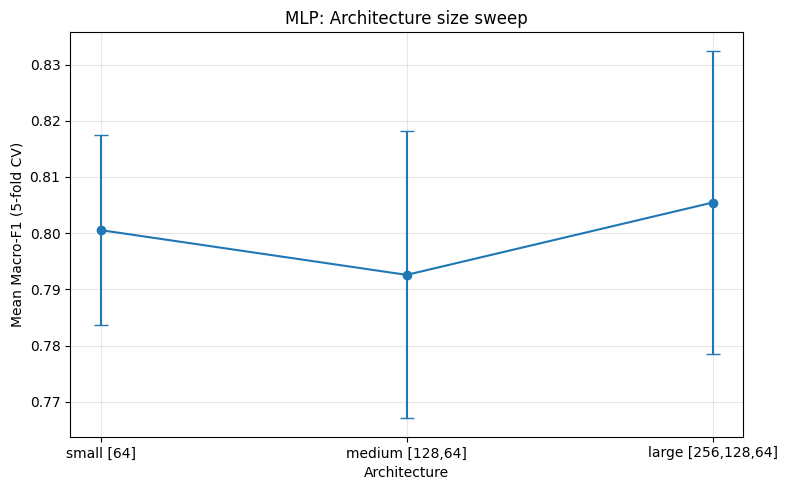

In [5]:
from sklearn.metrics import f1_score, classification_report
def run_mlp_config_across_folds(hidden_dims, dropout, lr, weight_decay):
    fold_f1_scores = []
    fold_predictions = []

    for fold in range(5):
        val_f1, preds, y_val = train_mlp_one_fold(
            fold, hidden_dims=hidden_dims, dropout=dropout, lr=lr, weight_decay=weight_decay
        )
        fold_f1_scores.append(val_f1)
        fold_predictions.append((y_val, preds))

    return np.mean(fold_f1_scores), np.std(fold_f1_scores), fold_f1_scores, fold_predictions


# Sweep 1: architecture size (fixed dropout/lr/weight_decay for now)
architectures = {
    'small [64]': [64],
    'medium [128,64]': [128, 64],
    'large [256,128,64]': [256, 128, 64],
}

arch_results = []
for name, hidden_dims in architectures.items():
    mean_f1, std_f1, fold_scores, _ = run_mlp_config_across_folds(
        hidden_dims=hidden_dims, dropout=0.3, lr=1e-3, weight_decay=1e-4
    )
    arch_results.append({'architecture': name, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"{name}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

arch_results_df = pd.DataFrame(arch_results)

plt.figure(figsize=(8, 5))
plt.errorbar(arch_results_df['architecture'], arch_results_df['mean_macro_f1'],
             yerr=arch_results_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('Architecture')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MLP: Architecture size sweep')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lr=0.0001: mean macro-F1=0.7946 (+/- 0.0214)
lr=0.0003: mean macro-F1=0.8135 (+/- 0.0165)
lr=0.001: mean macro-F1=0.7885 (+/- 0.0168)
lr=0.003: mean macro-F1=0.7858 (+/- 0.0311)
lr=0.01: mean macro-F1=0.5692 (+/- 0.0500)


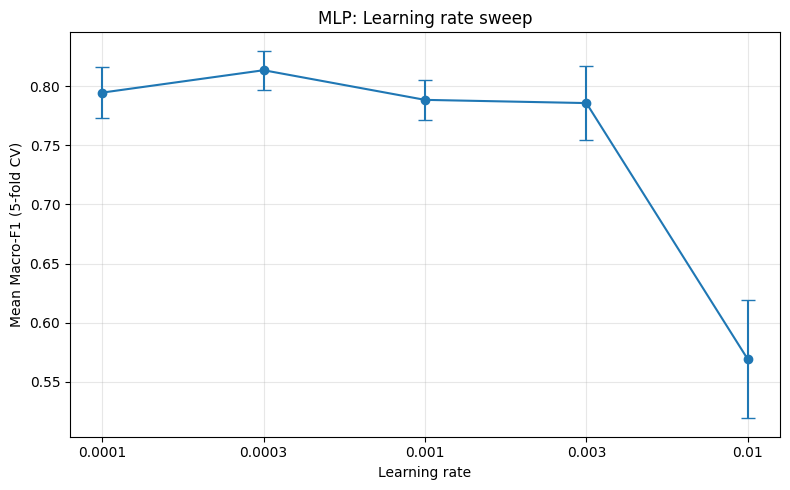

In [6]:
# Sweep 2: learning rate, holding architecture and dropout fixed
lr_values = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

lr_results = []
for lr in lr_values:
    mean_f1, std_f1, fold_scores, _ = run_mlp_config_across_folds(
        hidden_dims=[256, 128, 64], dropout=0.3, lr=lr, weight_decay=1e-4
    )
    lr_results.append({'lr': lr, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"lr={lr}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

lr_results_df = pd.DataFrame(lr_results)

plt.figure(figsize=(8, 5))
plt.errorbar(lr_results_df['lr'].astype(str), lr_results_df['mean_macro_f1'],
             yerr=lr_results_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('Learning rate')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MLP: Learning rate sweep')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
def train_mlp_one_fold(fold, hidden_dims, dropout, lr, weight_decay, epochs=100, patience=15, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train = torch.tensor(fold_data[fold]['gene_train'].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold]['gene_val'].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
    y_val_t = torch.tensor(y_val_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    X_val_dev = X_val.to(device)
    y_val_dev = y_val_t.to(device)

    best_val_f1 = -1
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(X_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)

    return best_val_f1, final_preds, fold_data[fold]['y_val']


# Sanity check: re-run the same config twice, confirm identical results now
r1, _, _ = train_mlp_one_fold(0, hidden_dims=[256,128,64], dropout=0.3, lr=3e-4, weight_decay=1e-4)
r2, _, _ = train_mlp_one_fold(0, hidden_dims=[256,128,64], dropout=0.3, lr=3e-4, weight_decay=1e-4)
print(f"Run 1: {r1:.4f}, Run 2: {r2:.4f}, Identical: {r1 == r2}")

Run 1: 0.7858, Run 2: 0.7858, Identical: True


dropout=0.1: mean macro-F1=0.7983 (+/- 0.0347)
dropout=0.2: mean macro-F1=0.8049 (+/- 0.0118)
dropout=0.3: mean macro-F1=0.7763 (+/- 0.0160)
dropout=0.4: mean macro-F1=0.7877 (+/- 0.0140)
dropout=0.5: mean macro-F1=0.8026 (+/- 0.0338)


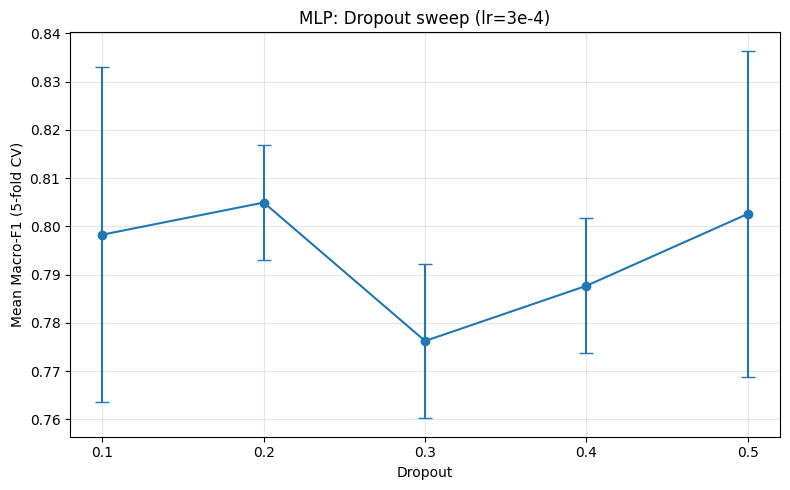

In [9]:
# Sweep 3: dropout, holding architecture and lr fixed
dropout_values = [0.1, 0.2, 0.3, 0.4, 0.5]

dropout_results = []
for dropout in dropout_values:
    mean_f1, std_f1, fold_scores, _ = run_mlp_config_across_folds(
        hidden_dims=[256, 128, 64], dropout=dropout, lr=3e-4, weight_decay=1e-4
    )
    dropout_results.append({'dropout': dropout, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"dropout={dropout}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

dropout_results_df = pd.DataFrame(dropout_results)

plt.figure(figsize=(8, 5))
plt.errorbar(dropout_results_df['dropout'].astype(str), dropout_results_df['mean_macro_f1'],
             yerr=dropout_results_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('Dropout')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MLP: Dropout sweep (lr=3e-4)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

small [64]: mean macro-F1=0.7774 (+/- 0.0207)
medium [128,64]: mean macro-F1=0.7865 (+/- 0.0240)
large [256,128,64]: mean macro-F1=0.8049 (+/- 0.0118)
xlarge [512,256,128,64]: mean macro-F1=0.8015 (+/- 0.0321)


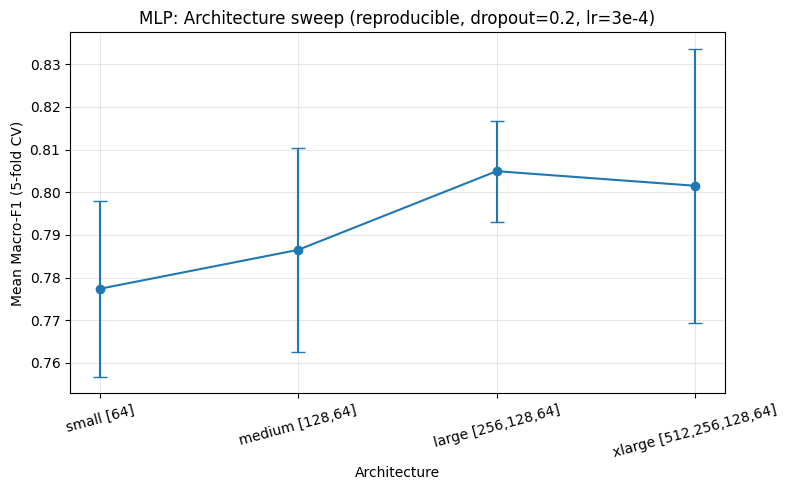

In [10]:
# Sweep 4: re-run architecture comparison now that results are reproducible
architectures = {
    'small [64]': [64],
    'medium [128,64]': [128, 64],
    'large [256,128,64]': [256, 128, 64],
    'xlarge [512,256,128,64]': [512, 256, 128, 64],
}

arch_results_v2 = []
for name, hidden_dims in architectures.items():
    mean_f1, std_f1, fold_scores, _ = run_mlp_config_across_folds(
        hidden_dims=hidden_dims, dropout=0.2, lr=3e-4, weight_decay=1e-4
    )
    arch_results_v2.append({'architecture': name, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"{name}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

arch_results_v2_df = pd.DataFrame(arch_results_v2)

plt.figure(figsize=(8, 5))
plt.errorbar(arch_results_v2_df['architecture'], arch_results_v2_df['mean_macro_f1'],
             yerr=arch_results_v2_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('Architecture')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MLP: Architecture sweep (reproducible, dropout=0.2, lr=3e-4)')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weight_decay=0: mean macro-F1=0.7966 (+/- 0.0241)
weight_decay=1e-05: mean macro-F1=0.7917 (+/- 0.0365)
weight_decay=0.0001: mean macro-F1=0.8049 (+/- 0.0118)
weight_decay=0.001: mean macro-F1=0.7913 (+/- 0.0112)
weight_decay=0.01: mean macro-F1=0.7863 (+/- 0.0193)


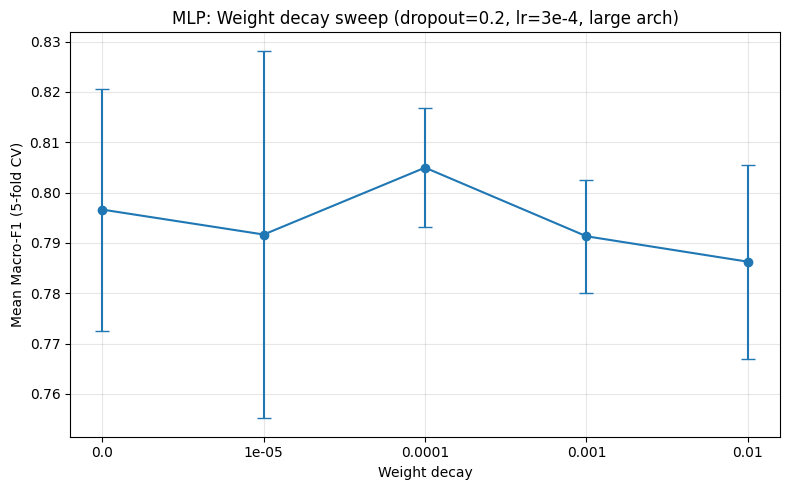

In [11]:
# Sweep 5: weight_decay, holding best architecture/dropout/lr fixed
weight_decay_values = [0, 1e-5, 1e-4, 1e-3, 1e-2]

wd_results = []
for wd in weight_decay_values:
    mean_f1, std_f1, fold_scores, _ = run_mlp_config_across_folds(
        hidden_dims=[256, 128, 64], dropout=0.2, lr=3e-4, weight_decay=wd
    )
    wd_results.append({'weight_decay': wd, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"weight_decay={wd}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

wd_results_df = pd.DataFrame(wd_results)

plt.figure(figsize=(8, 5))
plt.errorbar(wd_results_df['weight_decay'].astype(str), wd_results_df['mean_macro_f1'],
             yerr=wd_results_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('Weight decay')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MLP: Weight decay sweep (dropout=0.2, lr=3e-4, large arch)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import os

CHECKPOINT_DIR = f'{DATA_DIR}/mlp_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def train_mlp_final(fold, hidden_dims, dropout, lr, weight_decay,
                     epochs=300, patience=25, seed=42, save_checkpoint=True):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train = torch.tensor(fold_data[fold]['gene_train'].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold]['gene_val'].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
    y_val_t = torch.tensor(y_val_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    # LR scheduler: reduce LR when validation macro-F1 plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=8
    )

    X_val_dev = X_val.to(device)
    y_val_dev = y_val_t.to(device)

    best_val_f1 = -1
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_f1': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)

    if save_checkpoint:
        checkpoint_path = f'{CHECKPOINT_DIR}/mlp_fold{fold}_best.pt'
        torch.save({
            'model_state_dict': best_state,
            'hidden_dims': hidden_dims, 'dropout': dropout,
            'best_val_f1': best_val_f1, 'fold': fold,
        }, checkpoint_path)

    model.eval()
    with torch.no_grad():
        final_preds_enc = model(X_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)

    return best_val_f1, final_preds, fold_data[fold]['y_val'], history


# Run on all 5 folds with the locked best config
mlp_fold_scores = []
mlp_predictions = []
mlp_histories = []

for fold in range(5):
    val_f1, preds, y_val, history = train_mlp_final(
        fold, hidden_dims=[256, 128, 64], dropout=0.2, lr=3e-4, weight_decay=1e-4
    )
    mlp_fold_scores.append(val_f1)
    mlp_predictions.append((y_val, preds))
    mlp_histories.append(history)
    print(f"Fold {fold}: best val macro-F1={val_f1:.4f}, "
          f"epochs trained={len(history['val_f1'])}, "
          f"final LR={history['lr'][-1]:.2e}")

print(f"\nFinal MLP: mean macro-F1={np.mean(mlp_fold_scores):.4f} (+/- {np.std(mlp_fold_scores):.4f})")

Fold 0: best val macro-F1=0.8097, epochs trained=81, final LR=9.37e-06
Fold 1: best val macro-F1=0.7975, epochs trained=45, final LR=7.50e-05
Fold 2: best val macro-F1=0.8029, epochs trained=41, final LR=7.50e-05
Fold 3: best val macro-F1=0.7909, epochs trained=43, final LR=7.50e-05
Fold 4: best val macro-F1=0.8354, epochs trained=63, final LR=3.75e-05

Final MLP: mean macro-F1=0.8073 (+/- 0.0154)


In [13]:
all_y_true_mlp = np.concatenate([p[0] for p in mlp_predictions])
all_y_pred_mlp = np.concatenate([p[1] for p in mlp_predictions])

model_results['MLP'] = {
    'mean_macro_f1': np.mean(mlp_fold_scores),
    'std_macro_f1': np.std(mlp_fold_scores),
    'fold_scores': mlp_fold_scores,
    'predictions': mlp_predictions,
    'best_params': {'hidden_dims': [256, 128, 64], 'dropout': 0.2, 'lr': 3e-4, 'weight_decay': 1e-4}
}

print("Per-class report (aggregated across folds):")
print(classification_report(all_y_true_mlp, all_y_pred_mlp, zero_division=0))

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.82      0.81      0.81       326
       Mixed       0.71      0.74      0.73        27
          NR       0.93      0.91      0.92       774
        TCMR       0.71      0.86      0.78        81

    accuracy                           0.88      1208
   macro avg       0.79      0.83      0.81      1208
weighted avg       0.88      0.88      0.88      1208



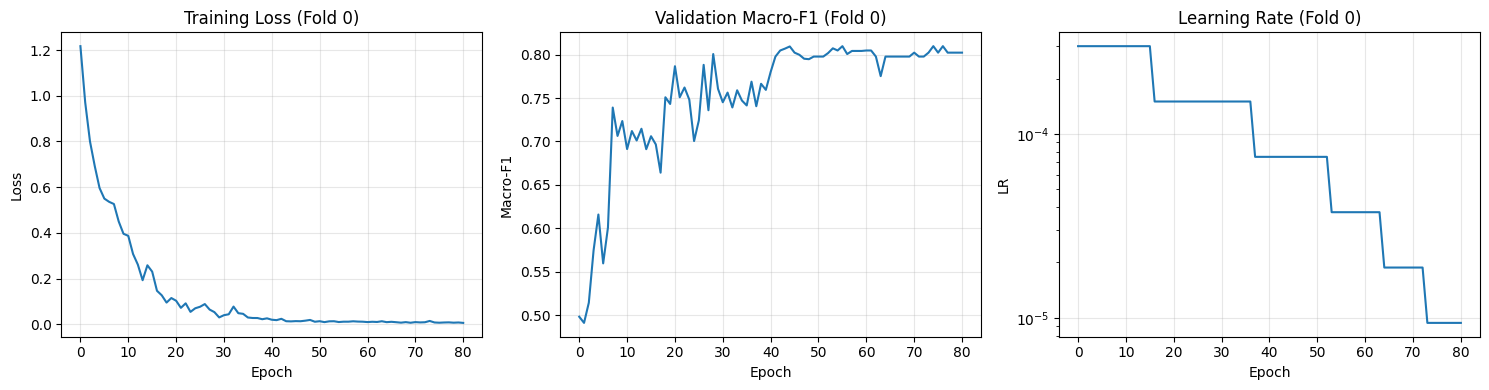

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(mlp_histories[0]['train_loss'])
axes[0].set_title('Training Loss (Fold 0)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_histories[0]['val_f1'])
axes[1].set_title('Validation Macro-F1 (Fold 0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-F1')
axes[1].grid(True, alpha=0.3)

axes[2].plot(mlp_histories[0]['lr'])
axes[2].set_title('Learning Rate (Fold 0)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

           model  mean_macro_f1  std_macro_f1
5            MLP       0.807262      0.015365
4        XGBoost       0.803542      0.029499
2            SVM       0.754018      0.050766
0          LASSO       0.746601      0.045541
1          Ridge       0.739190      0.072869
3  Random Forest       0.676986      0.043044


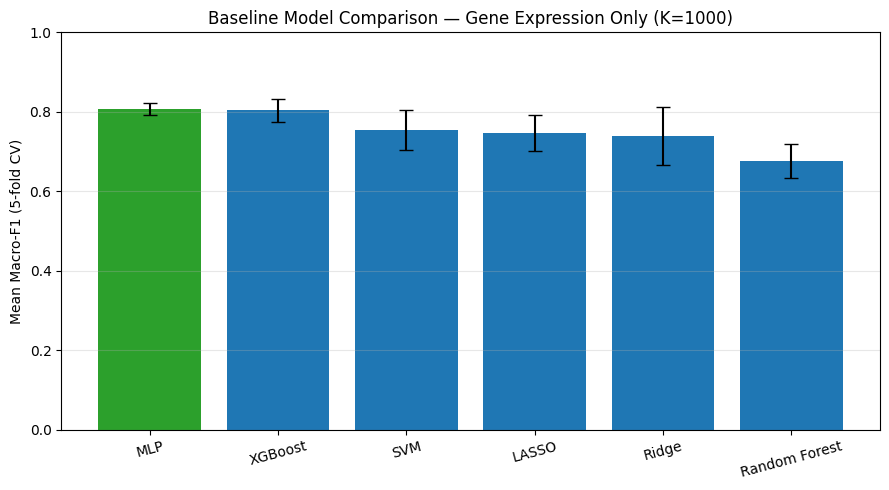


Saved updated model_results (now including MLP) to classical_baseline_results.pkl


In [15]:
comparison_data = []
for name, res in model_results.items():
    comparison_data.append({
        'model': name,
        'mean_macro_f1': res['mean_macro_f1'],
        'std_macro_f1': res['std_macro_f1']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('mean_macro_f1', ascending=False)
print(comparison_df)

plt.figure(figsize=(9, 5))
colors = ['#2ca02c' if m == comparison_df.iloc[0]['model'] else '#1f77b4' for m in comparison_df['model']]
plt.bar(comparison_df['model'], comparison_df['mean_macro_f1'],
        yerr=comparison_df['std_macro_f1'], capsize=5, color=colors)
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('Baseline Model Comparison — Gene Expression Only (K=1000)')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Save everything for reuse in the multimodal notebook
with open(f'{DATA_DIR}/classical_baseline_results.pkl', 'wb') as f:
    pickle.dump(model_results, f)
print("\nSaved updated model_results (now including MLP) to classical_baseline_results.pkl")